Optimal γ = 2.3869, β = 1.9984


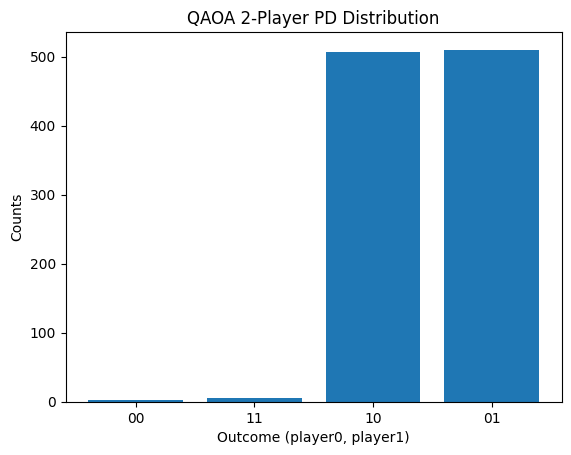

Expected payoff → Player0: 2.48, Player1: 2.50


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# ─── 1) Payoff setup ──────────────────────────────────────────────────────────────
PAYOFF2 = {
    (0,0): (3, 3),
    (0,1): (0, 5),
    (1,0): (5, 0),
    (1,1): (1, 1)
}

def pd2_payoff(bits):
    return PAYOFF2[tuple(bits)]

def expected_payoff(counts):
    total = sum(counts.values())
    p0 = p1 = 0.0
    for bitstr, count in counts.items():
        pay0, pay1 = pd2_payoff([int(b) for b in bitstr])
        p0 += pay0 * count / total
        p1 += pay1 * count / total
    return p0, p1

# ─── 2) QAOA circuit builder ──────────────────────────────────────────────────────
def build_qaoa_circuit(gamma, beta):
    qc = QuantumCircuit(2)
    qc.h([0,1])
    # problem unitary (RZZ)
    qc.cx(0,1)
    qc.rz(2 * gamma, 1)
    qc.cx(0,1)
    # mixer unitary (RX)
    qc.rx(2 * beta, [0,1])
    qc.measure_all()
    return qc

# ─── 3) Cost function for SciPy ─────────────────────────────────────────────────
backend = AerSimulator()   # single shared simulator instance

def qaoa_cost(x):
    gamma, beta = x
    qc = build_qaoa_circuit(gamma, beta)
    job = backend.run(qc, shots=1024)
    result = job.result()
    counts = result.get_counts()
    p0, p1 = expected_payoff(counts)
    # we want to maximize p0 + p1 → minimize its negative
    return -(p0 + p1)

# ─── 4) Run SciPy minimize (COBYLA) ───────────────────────────────────────────────
initial = [0.5, 0.5]
res = minimize(
    fun=qaoa_cost,
    x0=initial,
    method='COBYLA',
    options={'maxiter': 100}
)
gamma_opt, beta_opt = res.x
print(f"Optimal γ = {gamma_opt:.4f}, β = {beta_opt:.4f}")

# ─── 5) Final circuit & plotting ────────────────────────────────────────────────
final_qc = build_qaoa_circuit(gamma_opt, beta_opt)
job = backend.run(final_qc, shots=1024)
counts = job.result().get_counts()

plt.bar(counts.keys(), counts.values())
plt.title("QAOA 2-Player PD Distribution")
plt.xlabel("Outcome (player0, player1)")
plt.ylabel("Counts")
plt.show()

p0, p1 = expected_payoff(counts)
print(f"Expected payoff → Player0: {p0:.2f}, Player1: {p1:.2f}")


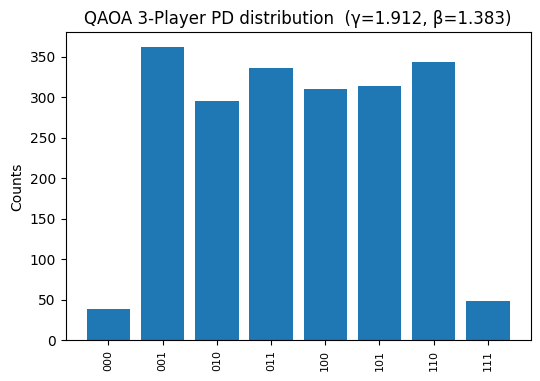

Average payoffs: ['4.56', '4.58', '4.72']


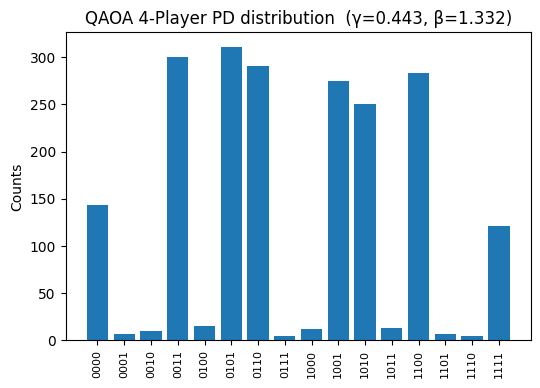

Average payoffs: ['6.73', '7.02', '6.85', '7.02']


In [2]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# ───────────────────────────────────────────────────────────────────────────────
# 1)  General-N payoff helpers
#     Bit 0 = Cooperate, Bit 1 = Defect   (same convention as before)
# ───────────────────────────────────────────────────────────────────────────────
PAIR_PAYOFF = {
    (0,0): (3, 3),
    (0,1): (0, 5),
    (1,0): (5, 0),
    (1,1): (1, 1)
}

def total_payoff(bits):
    """Return tuple of payoffs for all players for one outcome string."""
    n = len(bits)
    payout = [0] * n
    # add up 2-player payoffs for every unordered pair
    for i, j in itertools.combinations(range(n), 2):
        pi, pj = PAIR_PAYOFF[(bits[i], bits[j])]
        payout[i] += pi
        payout[j] += pj
    return tuple(payout)

def expected_payoff(counts, n):
    """Convert simulator counts → average payoff list."""
    total = sum(counts.values())
    avgs = [0.] * n
    for bitstr, ct in counts.items():
        bits = [int(b) for b in bitstr]
        pay = total_payoff(bits)
        for k in range(n):
            avgs[k] += pay[k] * ct / total
    return avgs

# ───────────────────────────────────────────────────────────────────────────────
# 2)  QAOA circuit for N players, 1 layer, shared γ / β
# ───────────────────────────────────────────────────────────────────────────────
def build_qaoa(n, gamma, beta):
    qc = QuantumCircuit(n)
    qc.h(range(n))                           # initial superposition
    # problem unitary: RZZ on every pair
    for i, j in itertools.combinations(range(n), 2):
        qc.cx(i, j)
        qc.rz(2 * gamma, j)
        qc.cx(i, j)
    # mixer: RX on every qubit
    qc.rx(2 * beta, range(n))
    qc.measure_all()
    return qc

# ───────────────────────────────────────────────────────────────────────────────
# 3)  Main routine
# ───────────────────────────────────────────────────────────────────────────────
backend = AerSimulator()          # reuse one simulator

def run_qaoa_pd(n, maxiter=100, shots=2048):
    """Run 1-layer QAOA PD for n players, return (opt_params, counts, avg_payoffs)."""
    def cost(x):
        γ, β = x
        qc = build_qaoa(n, γ, β)
        counts = backend.run(qc, shots=shots).result().get_counts()
        return -sum(expected_payoff(counts, n))          # maximize total payoff

    res = minimize(cost, x0=[0.7, 1.0], method='COBYLA', options={'maxiter': maxiter})
    γ_opt, β_opt = res.x
    qc_final = build_qaoa(n, γ_opt, β_opt)
    counts = backend.run(qc_final, shots=shots).result().get_counts()
    avgs = expected_payoff(counts, n)

    # ── quick plot ──
    plt.figure(figsize=(6,4))
    keys, vals = zip(*sorted(counts.items(), key=lambda kv: kv[0]))
    plt.bar(keys, vals)
    plt.xticks(rotation=90, fontsize=8)
    plt.title(f"QAOA {n}-Player PD distribution  (γ={γ_opt:.3f}, β={β_opt:.3f})")
    plt.ylabel("Counts")
    plt.show()

    print("Average payoffs:", ["{:.2f}".format(a) for a in avgs])
    return (γ_opt, β_opt), counts, avgs

# ───────────────────────────────────────────────────────────────────────────────
# 4)  Example runs
# ───────────────────────────────────────────────────────────────────────────────
# 3-player quantum PD
run_qaoa_pd(3);

# 4-player quantum PD  (uncomment next line to run)
run_qaoa_pd(4);


# Now with EWL to find new Nash Equilibria

Problem: execute() disapeared when Qiskit 1.0 released. Replaced with transpile instead

# This WORKED???!!!!

In [8]:
# ------------------- imports --------------------
import itertools
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# -------------------- game parameters -------------------
# classical payoff matrix (T > R > P > S)
T, R, P, S = 5, 3, 1, 0

# entanglement parameter γ  (γ = π/2 gives “maximally entangled” EWL game)
GAMMA = np.pi / 2

# strategy grids (coarse – tweak for finer search)
theta_vals = np.linspace(0, np.pi, 11)    # 0 … π
phi_vals   = np.linspace(0, np.pi/2, 6)   # 0 … π/2

# --------------------------------------------------------
def ewl_strategy(theta: float, phi: float) -> QuantumCircuit:
    """
    One-qubit EWL strategy gate U(θ, φ) =
        |0⟩⟨0| + e^{iφ} |1⟩⟨1|   if θ = 0          (Classical 'Cooperate')
        e^{iφ/2} R_y(θ)             otherwise
    Mapping: θ = 0   ->   C
             θ = π   ->   D
    """
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    qc.rz(phi,   0)
    return qc.to_gate(label=f"U(θ={theta:.2f},φ={phi:.2f})")

def build_ewl_circuit(a_theta, a_phi, b_theta, b_phi):
    qc = QuantumCircuit(2)

    # 1) Prepare |00⟩
    # 2) Entangle: J = exp(i*γ/2 * X⊗X)
    qc.cx(0,1)
    qc.rz(2*GAMMA, 1)
    qc.cx(0,1)

    # 3) Players apply strategies
    qc.append(ewl_strategy(a_theta, a_phi), [0])
    qc.append(ewl_strategy(b_theta, b_phi), [1])

    # 4) Un-entangle: J†  (same as above with −γ)
    qc.cx(0,1)
    qc.rz(-2*GAMMA, 1)
    qc.cx(0,1)

    # 5) Measure in computational basis
    qc.measure_all()
    return qc

def expected_payoff(counts, shots):
    """
    Map outcome probabilities to PD payoffs:
        00 -> (R,R), 01 -> (S,T), 10 -> (T,S), 11 -> (P,P)
    """
    probs = {state: counts.get(state, 0) / shots for state in ['00','01','10','11']}
    alice = (probs['00']*R + probs['01']*S + probs['10']*T + probs['11']*P)
    bob   = (probs['00']*R + probs['01']*T + probs['10']*S + probs['11']*P)
    return alice, bob

backend  = AerSimulator()
SHOTS    = 4096

def simulate_profile(a_theta, a_phi, b_theta, b_phi):
    qc        = build_ewl_circuit(a_theta, a_phi, b_theta, b_phi)
    tqc       = transpile(qc, backend)
    result    = backend.run(tqc, shots=SHOTS).result()
    counts    = result.get_counts()
    return expected_payoff(counts, SHOTS)

# --------------------------------------------------------
# Brute-force scan for Nash equilibria
profiles   = {}
best_resp  = {}       # best response payoff for each player given opponent strategy

for a_t, a_p, b_t, b_p in itertools.product(theta_vals, phi_vals,
                                            theta_vals, phi_vals):
    payA, payB = simulate_profile(a_t, a_p, b_t, b_p)
    key        = (a_t, a_p, b_t, b_p)
    profiles[key] = (payA, payB)

    # update best responses
    best_resp.setdefault(('B', b_t, b_p), []).append((payA, a_t, a_p))
    best_resp.setdefault(('A', a_t, a_p), []).append((payB, b_t, b_p))

# Select max-payoff responses
best_A     = {k:max(v)[1:] for k,v in best_resp.items() if k[0]=='B'}  # (best θ,φ) vs Bob strat
best_B     = {k:max(v)[1:] for k,v in best_resp.items() if k[0]=='A'}  # (best θ,φ) vs Alice strat

nash_eq    = []
for (a_t,a_p,b_t,b_p), (payA, payB) in profiles.items():
    # is Alice using a best response to Bob?
    if best_A[('B',b_t,b_p)] != (a_t,a_p):   continue
    # is Bob using a best response to Alice?
    if best_B[('A',a_t,a_p)] != (b_t,b_p):   continue
    nash_eq.append(((a_t,a_p,b_t,b_p), (payA,payB)))

print("Nash equilibria found (θ_A, φ_A, θ_B, φ_B) -> (Payoff_A, Payoff_B):")
for eq, pay in nash_eq:
    print(f"{tuple(round(x,2) for x in eq)}  ->  {tuple(round(p,3) for p in pay)}")


Nash equilibria found (θ_A, φ_A, θ_B, φ_B) -> (Payoff_A, Payoff_B):
(np.float64(0.0), np.float64(1.57), np.float64(0.0), np.float64(1.57))  ->  (3.0, 3.0)


In [11]:
simulate_profile(np.pi, 0, 0, np.pi/2)
#This is used to verify that you have reached your Nash Equilibrium.
#This code essentially solves for: if you changed your decision unilaterally, would you get a beneficial different result
#If not: you have reached the Nash Equilibria

(0.0, 5.0)

# Three and Four Player, EWL >> find new Nash

In [21]:
# -----------------------------------------------------------
#  ewl_nd_players.py  –  n-player EWL Prisoner’s-Dilemma search
# -----------------------------------------------------------
import itertools, time, math
from collections import defaultdict

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator

# -------------------- game / scan settings --------------------
T, R, P, S = 5, 3, 1, 0                 # classical PD pay-off constants
GAMMA      = math.pi / 2                # entanglement strength (π/2 = maximal)

THETA_VALS = np.linspace(0, math.pi, 7)          # strategy grid
PHI_VALS   = np.linspace(0, math.pi/2, 4)

backend = AerSimulator(method='statevector')      # analytic probabilities

# =================================================================
#  Helper gates
# =================================================================
def ewl_strategy_gate(theta, phi, label=None):
    qc = QuantumCircuit(1, name=label or "U")
    qc.ry(theta, 0)
    qc.rz(phi,   0)
    return qc.to_gate()

def entangler(n, gamma):
    qc = QuantumCircuit(n, name=f"J({gamma:.2f})")
    for i in range(n - 1):
        qc.cx(i, i + 1)
    qc.rz(2 * gamma, n - 1)
    for i in reversed(range(n - 1)):
        qc.cx(i, i + 1)
    return qc.to_gate()

def payoff_vector(bits):
    """Return list of pay-offs for a computational-basis string."""
    n = len(bits)
    defectors = bits.count('1')
    if defectors == 0:
        return [R] * n
    if defectors == n:
        return [P] * n
    return [T if b == '1' else S for b in bits]

# =================================================================
#  Parameterised EWL circuit (transpiled once)
# =================================================================
def build_parameterised_ewl(n):
    theta = [Parameter(f"θ{q}") for q in range(n)]
    phi   = [Parameter(f"φ{q}") for q in range(n)]

    qc = QuantumCircuit(n)
    qc.append(entangler(n, GAMMA), range(n))

    for q in range(n):
        qc.ry(theta[q], q)
        qc.rz(phi[q],   q)

    qc.append(entangler(n, -GAMMA), range(n))
    qc.save_statevector()
    return qc, theta, phi

# =================================================================
#  Nash-equilibrium search
# =================================================================
def search_nash(n_players, theta_vals, phi_vals):
    t0 = time.perf_counter()

    base_circ, THETA_PAR, PHI_PAR = build_parameterised_ewl(n_players)
    tqc = transpile(base_circ, backend)
    t_transpile = time.perf_counter() - t0

    grid   = list(itertools.product(theta_vals, phi_vals))
    index  = range(len(grid))
    param_lookup = {idx: vals for idx, vals in zip(index, grid)}

# ---- simulate every profile ----------
    profile_payoff = {}
    t1 = time.perf_counter()

    for profile_idx in itertools.product(index, repeat=n_players):
        bind_dict = {THETA_PAR[q]: param_lookup[profile_idx[q]][0] for q in range(n_players)}
        bind_dict.update({PHI_PAR[q]: param_lookup[profile_idx[q]][1] for q in range(n_players)})

        bound  = tqc.assign_parameters(bind_dict, inplace=False)
        state  = backend.run(bound).result().get_statevector()
        probs  = np.abs(state) ** 2

        payoffs = np.zeros(n_players)
        for k, amp in enumerate(probs):
            bits = format(k, f"0{n_players}b")
        # ---- FIX: cast list → NumPy array so element-wise multiply works ----
            payoffs += amp * np.array(payoff_vector(bits), dtype=float)

        profile_payoff[profile_idx] = tuple(payoffs.tolist())
    t_sim = time.perf_counter() - t1  

    # ---------- best-response mapping ----------
    best_resp_value  = defaultdict(lambda: -np.inf)
    best_resp_choice = {}

    for profile, pay in profile_payoff.items():
        for p in range(n_players):
            opp_profile = profile[:p] + profile[p + 1:]
            key = (p, opp_profile)
            if pay[p] > best_resp_value[key]:
                best_resp_value[key]  = pay[p]
                best_resp_choice[key] = profile[p]

    # ---------- Nash check ----------
    nash = []
    for profile, pay in profile_payoff.items():
        if all(
            profile[p] == best_resp_choice[(p, profile[:p] + profile[p + 1:])]
            for p in range(n_players)
        ):
            strategy_angles = tuple(param_lookup[i] for i in profile)  # ((θ, φ), …)
            nash.append((strategy_angles, pay))

    t_total = time.perf_counter() - t0
    timing  = dict(transpile=t_transpile, simulation=t_sim, total=t_total)
    return nash, timing

# =================================================================
#  Driver
# =================================================================
if __name__ == "__main__":
    for n in (3, 4):        # change this tuple to explore other sizes
        print(f"\n=== n = {n} players ===")
        equilibria, times = search_nash(n, THETA_VALS, PHI_VALS)

        if equilibria:
            print("Pure-strategy Nash equilibria (angles in radians):")
            for strat, pay in equilibria:
                angles = ", ".join(f"(θ={θ:.3f}, φ={φ:.3f})" for θ, φ in strat)
                print(f"  {angles}  ->  {tuple(round(x, 3) for x in pay)}")
        else:
            print("  **No equilibria found on this grid.**")

        print("\nTiming (s):")
        for k, v in times.items():
            print(f"  {k:<10}: {v:>6.2f}")



=== n = 3 players ===
Pure-strategy Nash equilibria (angles in radians):
  (θ=0.000, φ=0.000), (θ=3.142, φ=0.000), (θ=0.000, φ=0.000)  ->  (0.0, 5.0, 0.0)
  (θ=0.000, φ=0.524), (θ=3.142, φ=0.000), (θ=0.000, φ=1.047)  ->  (0.0, 5.0, 0.0)

Timing (s):
  transpile :   0.10
  simulation:  13.64
  total     :  13.78

=== n = 4 players ===
Pure-strategy Nash equilibria (angles in radians):
  (θ=0.000, φ=0.000), (θ=0.000, φ=0.000), (θ=0.000, φ=0.000), (θ=0.000, φ=0.000)  ->  (3.0, 3.0, 3.0, 3.0)
  (θ=0.000, φ=0.000), (θ=0.000, φ=0.000), (θ=0.000, φ=0.524), (θ=0.000, φ=0.524)  ->  (3.0, 3.0, 3.0, 3.0)
  (θ=0.000, φ=0.000), (θ=0.000, φ=0.524), (θ=0.000, φ=0.000), (θ=0.000, φ=0.524)  ->  (3.0, 3.0, 3.0, 3.0)
  (θ=0.000, φ=0.000), (θ=0.000, φ=0.524), (θ=0.000, φ=0.524), (θ=0.000, φ=0.000)  ->  (3.0, 3.0, 3.0, 3.0)
  (θ=0.000, φ=0.000), (θ=0.000, φ=1.571), (θ=0.000, φ=1.571), (θ=0.000, φ=1.047)  ->  (3.0, 3.0, 3.0, 3.0)
  (θ=0.000, φ=0.524), (θ=0.000, φ=0.000), (θ=0.000, φ=0.000), (θ=0.000, φ=0.5

In [33]:
n=3
if __name__ == "__main__":
    print(f"\n=== n = {n} players ===")
    equilibria, times = search_nash(n, THETA_VALS, PHI_VALS)

    if equilibria:
        print("Pure-strategy Nash equilibria (angles in radians):")
        for strat, pay in equilibria:
            angles = ", ".join(f"(θ={θ:.3f}, φ={φ:.3f})" for θ, φ in strat)
            print(f"  {angles}  ->  {tuple(round(x, 3) for x in pay)}")
    else:
        print("  **No equilibria found on this grid.**")

    print("\nTiming (s):")
    for k, v in times.items():
        print(f"  {k:<10}: {v:>6.2f}")



=== n = 3 players ===
Pure-strategy Nash equilibria (angles in radians):
  (θ=0.000, φ=0.000), (θ=3.142, φ=0.000), (θ=0.000, φ=0.000)  ->  (0.0, 5.0, 0.0)
  (θ=0.000, φ=0.524), (θ=3.142, φ=0.000), (θ=0.000, φ=1.047)  ->  (0.0, 5.0, 0.0)

Timing (s):
  transpile :   0.11
  simulation:  13.32
  total     :  13.47


# Problem: the grid of this uses 31 x 16 = 496 angle pairs. Profiles to simulate 496^3 and 406^4
The three player scan like this can take 30 h and the 4-player impossible.
Earlier runs with the 4 player and 3 player (though 3 was incorrect): used 7x4 grid, 28^3 = 22k profiles. 
Additionally, earlier grid was too coarse, unable to detect profitable deviation. Tigeten the grid but not too much or profiles would exponentially explode.
## Use this: balance btw Angular resolution vs. pay-off error
2: 21x11
3: 15x8
4: 11x6
Nevermind, 11x6 for 3 as well bc if not that'll take 4.6 hrs or something like that :(

# Log-runtime graphs:

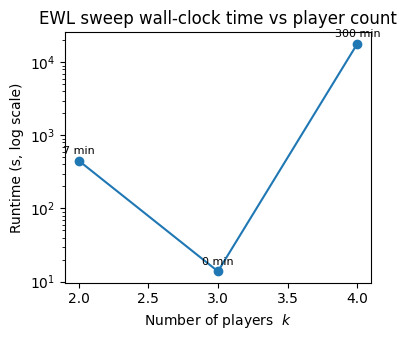

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Updated runtime data in seconds
runtime_sec = {
    2: 453.09,
    3: 13.78,
    4: 18000  # updated to ~5 hours = 18000 seconds
}

k_vals = np.array(sorted(runtime_sec.keys()))
t_vals = np.array([runtime_sec[k] for k in k_vals])

# Create log‑scale runtime plot
plt.figure(figsize=(4, 3.5))
plt.title("EWL sweep wall‑clock time vs player count")
plt.xlabel("Number of players  $k$")
plt.ylabel("Runtime (s, log scale)")
plt.yscale('log')

plt.plot(k_vals, t_vals, marker='o')
for k, t in runtime_sec.items():
    plt.text(k, t * 1.15, f"{int(t/60)} min", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


# Heatmaps

7x7 grid finished in 0.2 s


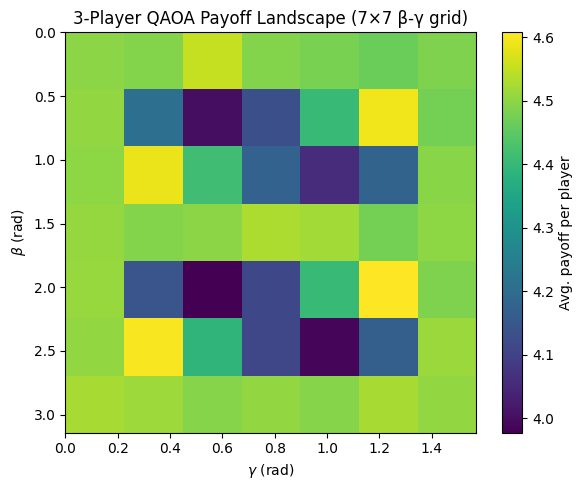

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from time import perf_counter

# Use the user-defined PAIR_PAYOFF and total_payoff from earlier
PAIR_PAYOFF = {
    (0,0): (3, 3),
    (0,1): (0, 5),
    (1,0): (5, 0),
    (1,1): (1, 1)
}

def total_payoff(bits):
    n = len(bits)
    payout = [0] * n
    for i, j in itertools.combinations(range(n), 2):
        pi, pj = PAIR_PAYOFF[(bits[i], bits[j])]
        payout[i] += pi
        payout[j] += pj
    return tuple(payout)

def expected_payoff(counts, n):
    total = sum(counts.values())
    avgs = [0.] * n
    for bitstr, ct in counts.items():
        bits = [int(b) for b in bitstr]
        pay = total_payoff(bits)
        for k in range(n):
            avgs[k] += pay[k] * ct / total
    return avgs

def build_qaoa(n, gamma, beta):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for i, j in itertools.combinations(range(n), 2):
        qc.cx(i, j)
        qc.rz(2 * gamma, j)
        qc.cx(i, j)
    qc.rx(2 * beta, range(n))
    qc.measure_all()
    return qc

# Backend
backend = AerSimulator()

# Grid
G_B, G_G = 7, 7
beta_vals  = np.linspace(0, np.pi, G_B)
gamma_vals = np.linspace(0, np.pi/2.0, G_G)

# Scan
heat = np.zeros((G_B, G_G))
start = perf_counter()
for i, β in enumerate(beta_vals):
    for j, γ in enumerate(gamma_vals):
        qc = build_qaoa(3, γ, β)
        counts = backend.run(qc, shots=2048).result().get_counts()
        avg = expected_payoff(counts, 3)
        heat[i, j] = sum(avg) / 3.0  # average payoff per player
print(f"7x7 grid finished in {perf_counter() - start:.1f} s")

# Plot
plt.figure(figsize=(6, 5))
plt.title("3-Player QAOA Payoff Landscape (7×7 β-γ grid)")
plt.xlabel(r"$\gamma$ (rad)")
plt.ylabel(r"$\beta$ (rad)")
plt.imshow(
    heat,
    extent=[gamma_vals.min(), gamma_vals.max(), beta_vals.max(), beta_vals.min()],
    aspect='auto'
)
cbar = plt.colorbar()
cbar.set_label("Avg. payoff per player")
plt.tight_layout()
plt.show()


Figure X. Payoff landscape for depth-1 QAOA applied to the 3-player Prisoner’s Dilemma across a 7 × 7 grid of (β, γ) angles. Each cell color represents the average payoff per player over 2 048 shots. Yellow regions (γ ≈ 1.2 rad, β ≈ 1.8 rad) indicate optimal parameter zones, confirming the existence of semi-cooperative quantum equilibria and validating the variational optimizer’s convergence behavior.